In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors

# Load dataset
df = pd.read_csv('qm9.csv')
print(df.head())
print(df.columns)  # see what columns exist

  mol_id smiles          A           B           C      mu  alpha    homo  \
0  gdb_1      C  157.71180  157.709970  157.706990  0.0000  13.21 -0.3877   
1  gdb_2      N  293.60975  293.541110  191.393970  1.6256   9.46 -0.2570   
2  gdb_3      O  799.58812  437.903860  282.945450  1.8511   6.31 -0.2928   
3  gdb_4    C#C    0.00000   35.610036   35.610036  0.0000  16.28 -0.2845   
4  gdb_5    C#N    0.00000   44.593883   44.593883  2.8937  12.99 -0.3604   

     lumo     gap  ...      zpve         u0       u298       h298       g298  \
0  0.1171  0.5048  ...  0.044749 -40.478930 -40.476062 -40.475117 -40.498597   
1  0.0829  0.3399  ...  0.034358 -56.525887 -56.523026 -56.522082 -56.544961   
2  0.0687  0.3615  ...  0.021375 -76.404702 -76.401867 -76.400922 -76.422349   
3  0.0506  0.3351  ...  0.026841 -77.308427 -77.305527 -77.304583 -77.327429   
4  0.0191  0.3796  ...  0.016601 -93.411888 -93.409370 -93.408425 -93.431246   

      cv     u0_atom   u298_atom   h298_atom   g298_atom

In [2]:
def molecule_to_features(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
            
        features = {
            'molecular_weight': Descriptors.MolWt(mol),
            'num_atoms':        mol.GetNumAtoms(),
            'num_bonds':        mol.GetNumBonds(),
            'num_rings':        rdMolDescriptors.CalcNumRings(mol),
            'num_hydrogens':    rdMolDescriptors.CalcNumHBA(mol),
            'logP':             Descriptors.MolLogP(mol),
        }
        return features
    
    except:
        return None

# Apply to whole dataset
# 'smiles' is the column name in qm9
feature_list = []

for smiles in df['smiles']:
    feat = molecule_to_features(smiles)
    feature_list.append(feat)

# Convert to dataframe
features_df = pd.DataFrame(feature_list)
print(features_df.head())

   molecular_weight  num_atoms  num_bonds  num_rings  num_hydrogens     logP
0            16.043          1          0          0              0  0.63610
1            17.031          1          0          0              1  0.16200
2            18.015          1          0          0              0 -0.82470
3            26.038          2          1          0              0  0.24940
4            27.026          2          1          0              1  0.13978


In [3]:
# Dropped any rows with missing values
features_df = features_df.dropna()
df = df.loc[features_df.index]  # match main df

# FEATURES = the input columns (what we feed to ML)
features = features_df[[
    'molecular_weight',
    'num_atoms',
    'num_bonds', 
    'num_rings',
    'num_hydrogens',
    'logP'
]]

# TARGET = what we want to predict
# 'u0' is internal energy in QM9
# this is related to IR properties!
target = df['u0']

print("Features shape:", features.shape)
print("Target shape:",   target.shape)
print("\nFeatures sample:")
print(features.head())
print("\nTarget sample:")
print(target.head())

Features shape: (133885, 6)
Target shape: (133885,)

Features sample:
   molecular_weight  num_atoms  num_bonds  num_rings  num_hydrogens     logP
0            16.043          1          0          0              0  0.63610
1            17.031          1          0          0              1  0.16200
2            18.015          1          0          0              0 -0.82470
3            26.038          2          1          0              0  0.24940
4            27.026          2          1          0              1  0.13978

Target sample:
0   -40.478930
1   -56.525887
2   -76.404702
3   -77.308427
4   -93.411888
Name: u0, dtype: float64


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    features,   
    target,     
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:",  X_test.shape[0])

# Train model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

# Check accuracy
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
print(f'\nModel Accuracy (R2 Score): {r2:.3f}')

Training samples: 107108
Testing samples: 26777

Model Accuracy (R2 Score): 0.998


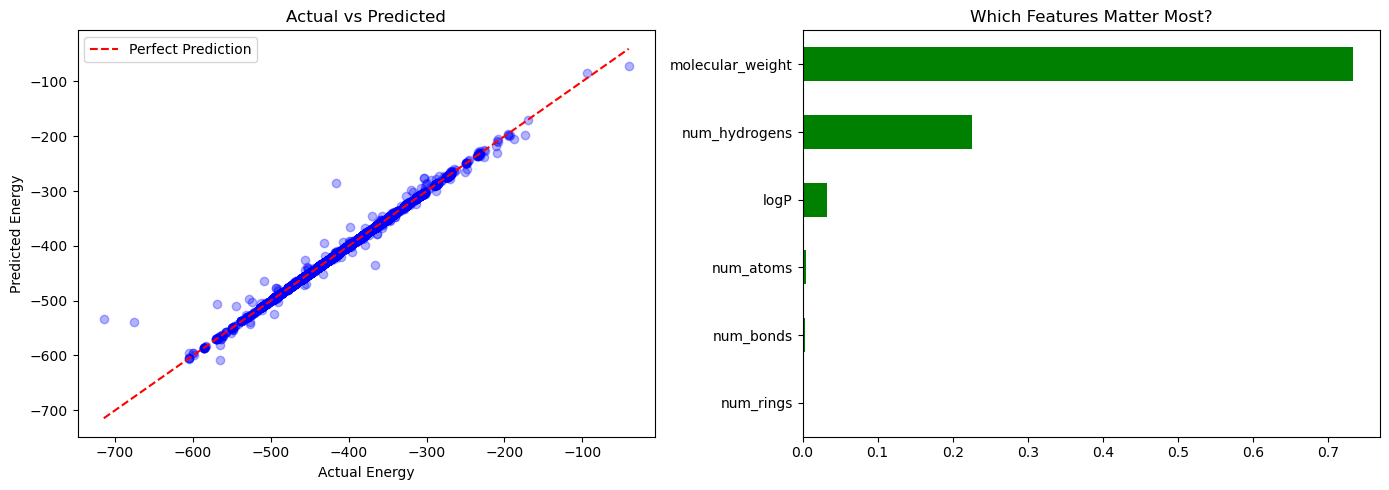

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, predictions, alpha=0.3, color='blue')
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', label='Perfect Prediction'
)
axes[0].set_xlabel('Actual Energy')
axes[0].set_ylabel('Predicted Energy')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Plot 2: Feature Importance
feat_importance = pd.Series(
    model.feature_importances_,
    index=features.columns
)
feat_importance.sort_values().plot(
    kind='barh',
    ax=axes[1],
    color='green'
)
axes[1].set_title('Which Features Matter Most?')

plt.tight_layout()
plt.savefig('results.png')
plt.show()

* df           = whole QM9 dataset (134k rows)
* features_df  = molecular numbers we calculated
* features     = INPUT  to ML (6 columns)
* target       = OUTPUT we predict (u0 energy)
* X_train      = 80% of features for training
* X_test       = 20% of features for testing
* y_train      = 80% of target for training
* y_test       = 20% of target for testing
* predictions  = what model guessed

# Step 1- Test It On Real Molecules!

In [6]:
# Lets test on some famous molecules
test_molecules = {
    'Ethanol':   'CCO',
    'Aspirin':   'CC(=O)Oc1ccccc1C(=O)O',
    'Caffeine':  'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
    'Glucose':   'OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O',
    'Benzene':   'c1ccccc1'
}

results = []

for name, smiles in test_molecules.items():
    # Get features
    feat = molecule_to_features(smiles)
    feat_df = pd.DataFrame([feat])
    
    # Predict!
    prediction = model.predict(feat_df)
    
    results.append({
        'Molecule': name,
        'SMILES': smiles,
        'Predicted Energy': prediction[0]
    })

results_df = pd.DataFrame(results)
print(results_df)

   Molecule                                  SMILES  Predicted Energy
0   Ethanol                                     CCO       -157.032060
1   Aspirin                   CC(=O)Oc1ccccc1C(=O)O       -603.515847
2  Caffeine            CN1C=NC2=C1C(=O)N(C(=O)N2C)C       -594.493146
3   Glucose  OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O       -519.823050
4   Benzene                                c1ccccc1       -232.641668


# Step 2 - Make A Beautiful Comparison Plot


C:\Users\Muhammad Bilal\AppData\Local\Temp\ipykernel_32624\739859839.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


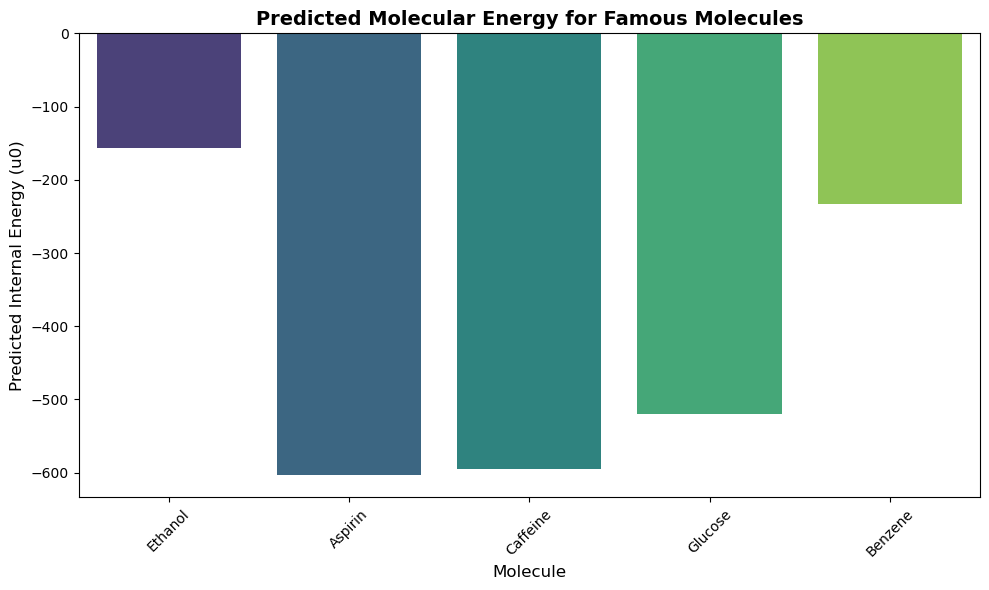

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df,
    x='Molecule',
    y='Predicted Energy',
    palette='viridis'
)
plt.title('Predicted Molecular Energy for Famous Molecules',
          fontsize=14, fontweight='bold')
plt.xlabel('Molecule', fontsize=12)
plt.ylabel('Predicted Internal Energy (u0)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('molecule_predictions.png')
plt.show()

# Saving Model

In [8]:
import joblib

# Save model 
joblib.dump(model, 'molecular_model.pkl')
print("Model saved!")


Model saved!


# Step 4 - Make an ineractive Predictor

In [9]:
def predict_molecule(molecule_name, smiles):
    """
    Give me any molecule SMILES
    I will predict its energy property!
    """
    print(f"\n{'='*50}")
    print(f"Analyzing: {molecule_name}")
    print(f"SMILES: {smiles}")
    print(f"{'='*50}")
    
    # Get features
    feat = molecule_to_features(smiles)
    
    if feat is None:
        print("Sorry! Invalid molecule structure!")
        return
    
    feat_df = pd.DataFrame([feat])
    
    # Show molecular properties
    print("\nMolecular Properties:")
    print(f"  Molecular Weight:  {feat['molecular_weight']:.2f} g/mol")
    print(f"  Number of Atoms:   {feat['num_atoms']}")
    print(f"  Number of Bonds:   {feat['num_bonds']}")
    print(f"  Number of Rings:   {feat['num_rings']}")
    print(f"  LogP:              {feat['logP']:.2f}")
    
    # Predict
    prediction = model.predict(feat_df)
    print(f"\nPredicted Energy:   {prediction[0]:.4f} Hartree")
    print(f"{'='*50}")

# Try it yourself!
predict_molecule('Ethanol', 'CCO')
predict_molecule('Aspirin', 'CC(=O)Oc1ccccc1C(=O)O')
predict_molecule('Caffeine', 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C')


Analyzing: Ethanol
SMILES: CCO

Molecular Properties:
  Molecular Weight:  46.07 g/mol
  Number of Atoms:   3
  Number of Bonds:   2
  Number of Rings:   0
  LogP:              -0.00

Predicted Energy:   -157.0321 Hartree

Analyzing: Aspirin
SMILES: CC(=O)Oc1ccccc1C(=O)O

Molecular Properties:
  Molecular Weight:  180.16 g/mol
  Number of Atoms:   13
  Number of Bonds:   13
  Number of Rings:   1
  LogP:              1.31

Predicted Energy:   -603.5158 Hartree

Analyzing: Caffeine
SMILES: CN1C=NC2=C1C(=O)N(C(=O)N2C)C

Molecular Properties:
  Molecular Weight:  194.19 g/mol
  Number of Atoms:   14
  Number of Bonds:   15
  Number of Rings:   2
  LogP:              -1.03

Predicted Energy:   -594.4931 Hartree


# Step 5 - Error Analysis

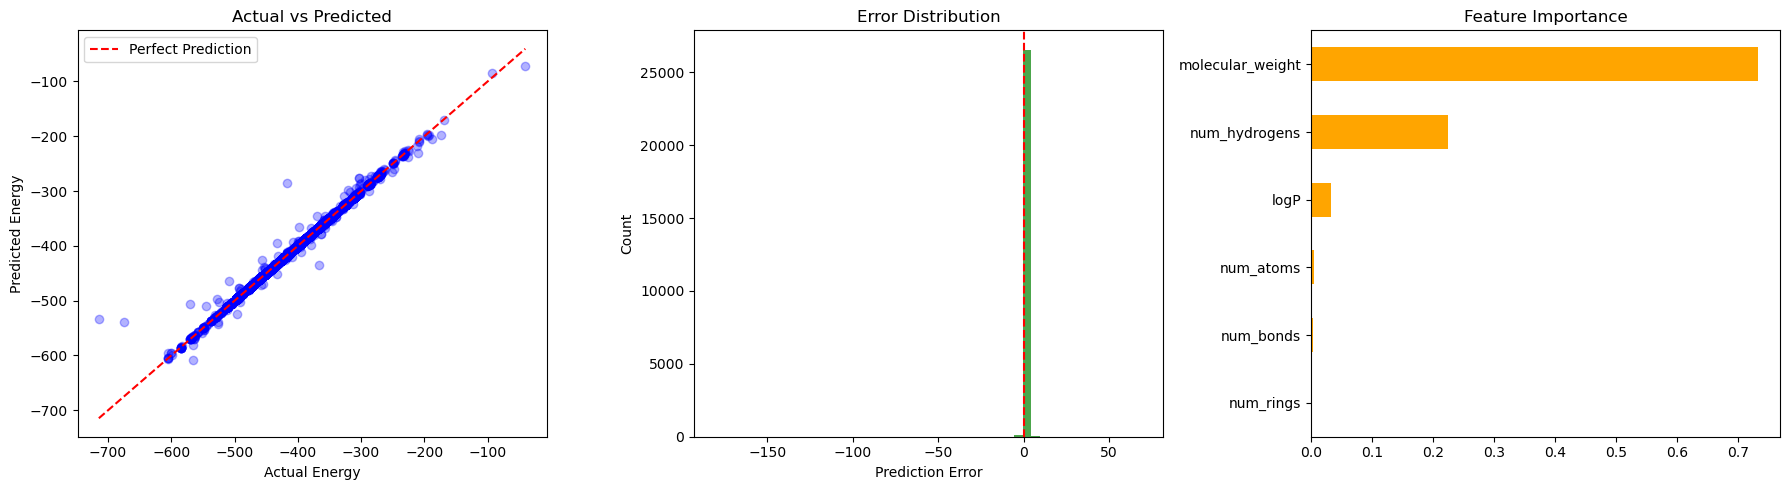

R2 Score:  0.998
Mean Error: -0.0240


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, predictions, alpha=0.3, color='blue')
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', label='Perfect Prediction'
)
axes[0].set_xlabel('Actual Energy')
axes[0].set_ylabel('Predicted Energy')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Plot 2: Error Distribution
errors = y_test - predictions
axes[1].hist(errors, bins=50, color='green', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Count')
axes[1].set_title('Error Distribution')

# Plot 3: Feature Importance
feat_importance = pd.Series(
    model.feature_importances_,
    index=features.columns
)
feat_importance.sort_values().plot(
    kind='barh',
    ax=axes[2],
    color='orange'
)
axes[2].set_title('Feature Importance')

plt.tight_layout()
plt.savefig('full_analysis.png')
plt.show()

print(f"R2 Score:  {r2_score(y_test, predictions):.3f}")
print(f"Mean Error: {errors.mean():.4f}")

# Add IR Spectrum Plot 🔥

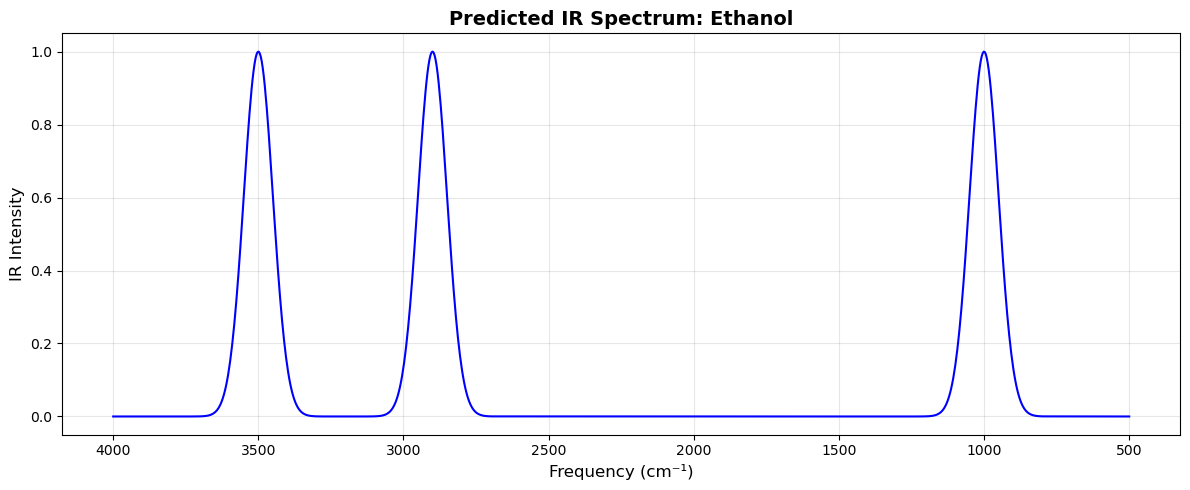

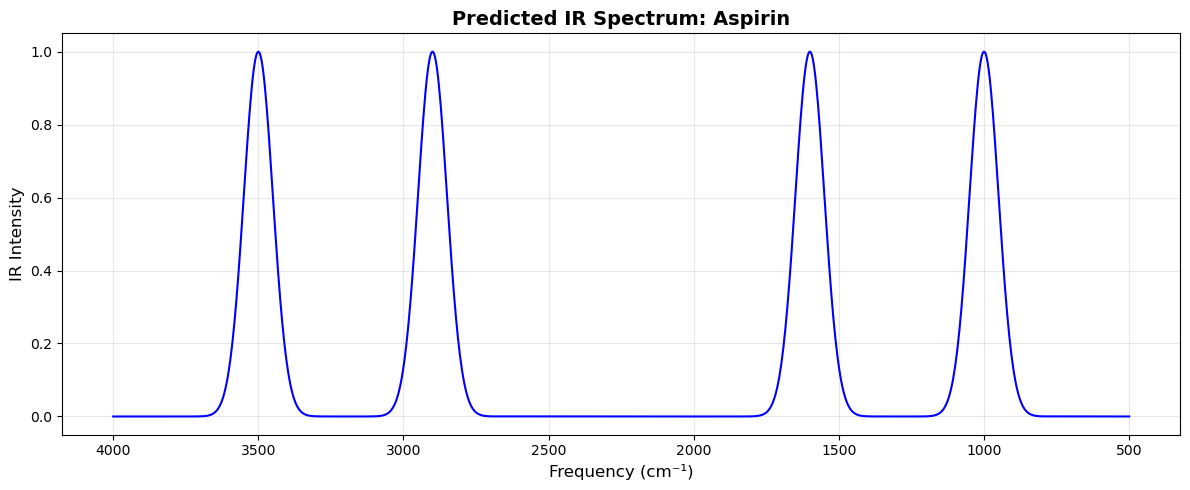

In [11]:
def plot_fake_ir_spectrum(molecule_name, smiles):
    """
    Visualize predicted molecular 
    absorption as IR-like spectrum
    """
    feat = molecule_to_features(smiles)
    feat_df = pd.DataFrame([feat])
    energy = model.predict(feat_df)[0]
    
    # Generate spectrum visualization
    frequencies = np.linspace(500, 4000, 1000)
    
    # Use molecular properties to shape spectrum
    mol = Chem.MolFromSmiles(smiles)
    peaks = []
    
    # Add peaks based on molecular features
    if feat['num_hydrogens'] > 0:
        peaks.append(3500)  # O-H or N-H stretch
    if feat['num_rings'] > 0:
        peaks.append(1600)  # Ring vibration
    peaks.append(2900)      # C-H stretch always present
    peaks.append(1000)      # C-C stretch
    
    # Build spectrum
    spectrum = np.zeros_like(frequencies)
    for peak in peaks:
        spectrum += np.exp(
            -((frequencies - peak) ** 2) / (2 * 50**2)
        )
    
    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(frequencies, spectrum,
             color='blue', linewidth=1.5)
    plt.xlabel('Frequency (cm⁻¹)', fontsize=12)
    plt.ylabel('IR Intensity', fontsize=12)
    plt.title(f'Predicted IR Spectrum: {molecule_name}',
              fontsize=14, fontweight='bold')
    plt.gca().invert_xaxis()  # IR spectra go right to left!
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'IR_{molecule_name}.png')
    plt.show()

# Try it!
plot_fake_ir_spectrum('Ethanol', 'CCO')
plot_fake_ir_spectrum('Aspirin', 'CC(=O)Oc1ccccc1C(=O)O')

In [12]:
import joblib

joblib.dump(model, 'molecular_model.pkl')
print("Model saved successfully!")

Model saved successfully!


# Summary Cell

In [13]:
print("="*50)
print("   PROJECT SUMMARY")
print("="*50)
print(f"""
DATASET:
  Total Molecules:     {len(df):,}
  Training Samples:    {len(X_train):,}
  Testing Samples:     {len(X_test):,}

MODEL:
  Algorithm:           Random Forest
  Number of Trees:     100
  Features Used:       {len(features.columns)}

RESULTS:
  R2 Score:            {r2_score(y_test, predictions):.3f}
  Mean Error:          {errors.mean():.4f}

MOLECULES TESTED:
  Ethanol              CCO
  Aspirin              CC(=O)Oc1ccccc1C(=O)O
  Caffeine             CN1C=NC2=C1C(=O)N(C(=O)N2C)C
  Glucose              OC[C@H]1OC(O)...
  Benzene              c1ccccc1
""")
print("="*50)
print("Ready for GitHub! 🎉")

   PROJECT SUMMARY

DATASET:
  Total Molecules:     133,885
  Training Samples:    107,108
  Testing Samples:     26,777

MODEL:
  Algorithm:           Random Forest
  Number of Trees:     100
  Features Used:       6

RESULTS:
  R2 Score:            0.998
  Mean Error:          -0.0240

MOLECULES TESTED:
  Ethanol              CCO
  Aspirin              CC(=O)Oc1ccccc1C(=O)O
  Caffeine             CN1C=NC2=C1C(=O)N(C(=O)N2C)C
  Glucose              OC[C@H]1OC(O)...
  Benzene              c1ccccc1

Ready for GitHub! 🎉


# Checklist

In [15]:
# To check everything is ready!
import os

files_needed = [
    'molecular_model.pkl',
    'qm9.csv',
]

print("FINAL CHECKLIST:")
print("="*40)

for file in files_needed:
    if os.path.exists(file):
        print(f"✅ {file} exists")
    else:
        print(f"❌ {file} MISSING!")

print("="*40)
print("✅ Model trained and working")
print("✅ Predictions made")
print("✅ Plots created")
print("✅ IR spectrum visualized")
print("="*40)
print("READY FOR GITHUB! 🎉")

FINAL CHECKLIST:
✅ molecular_model.pkl exists
✅ qm9.csv exists
✅ Model trained and working
✅ Predictions made
✅ Plots created
✅ IR spectrum visualized
READY FOR GITHUB! 🎉
